<a href="https://colab.research.google.com/github/vitriadwiernita/TUGAS-ANALISIS-KORELASI/blob/main/PROYEK_ETS_ANALISIS_REGRESI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NAMA : VITRIA DWI ERNITA**

**NIM : 2430109040001**

**MATA KULIAH : ANALISIS REGRESI**

# **Analisis Hubungan Durasi Screen Time terhadap Tingkat Stres Menggunakan Regresi Linear Sederhana**

---
---

Perkembangan teknologi digital menyebabkan peningkatan penggunaan perangkat elektronik dalam kehidupan sehari-hari. Aktivitas seperti penggunaan smartphone dan media sosial telah menjadi bagian dari rutinitas banyak orang. Namun, penggunaan perangkat digital yang berlebihan diduga dapat memengaruhi kondisi kesehatan mental seseorang, seperti meningkatnya tingkat stres.

Oleh karena itu, penting untuk menganalisis apakah terdapat hubungan antara durasi penggunaan perangkat digital (screen time) dengan tingkat stres seseorang.

Analisis ini dapat dilakukan menggunakan regresi linear sederhana, yang bertujuan untuk mengetahui apakah perubahan pada satu variabel dapat memengaruhi variabel lainnya.



---

---





Saving KEBIASAAN DIGITAL VS MENTAL HEALTH.csv to KEBIASAAN DIGITAL VS MENTAL HEALTH.csv
   screen_time_hours  stress_level
0                103            10
1                 65             8
2                 91             7
3                 65             7
4                 21             2

=== MISSING VALUES ===
screen_time_hours    0
stress_level         0
dtype: int64

=== OUTLIER DETECTION ===

Variabel: screen_time_hours
Jumlah outlier (IQR): 414
Jumlah outlier (Z-score): 145
Batas bawah: 8.0
Batas atas: 112.0

Variabel: stress_level
Jumlah outlier (IQR): 0
Jumlah outlier (Z-score): 0
Batas bawah: 0.5
Batas atas: 12.5


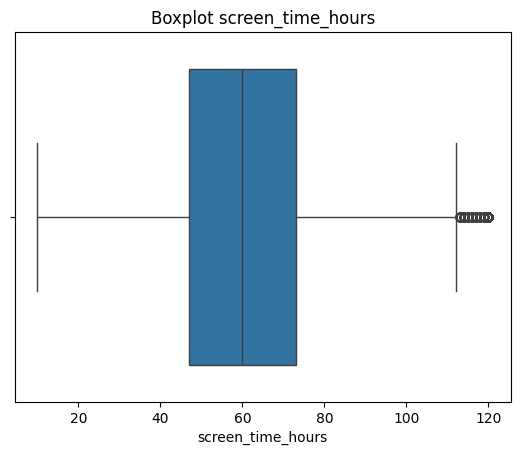

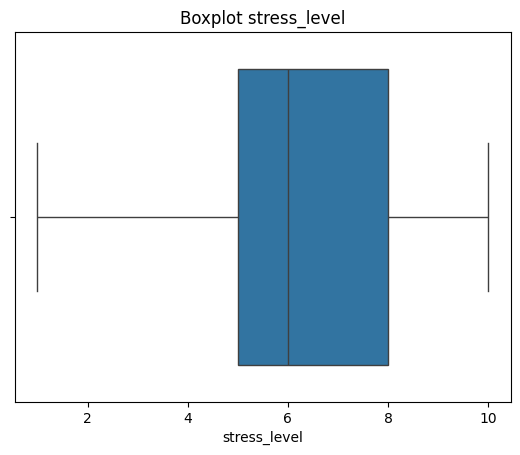


=== STATISTIK DESKRIPTIF ===
       screen_time_hours   stress_level
count      100000.000000  100000.000000
mean           60.035050       6.179590
std            19.870733       2.045409
min            10.000000       1.000000
25%            47.000000       5.000000
50%            60.000000       6.000000
75%            73.000000       8.000000
max           120.000000      10.000000

=== KORELASI ===
Koefisien Korelasi (r): 0.4941
p-value: 0.0
Interpretasi: Korelasi sedang

=== REGRESI LINEAR ===
                            OLS Regression Results                            
Dep. Variable:           stress_level   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                 3.230e+04
Date:                Wed, 01 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:24:39   Log-Likelihood:            -1.9946e+05
No. Observations:   

/tmp/ipykernel_5575/978970973.py:94: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = model.params[0]
/tmp/ipykernel_5575/978970973.py:95: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = model.params[1]
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 100000.
  res = hypotest_fun_out(*samples, **kwds)


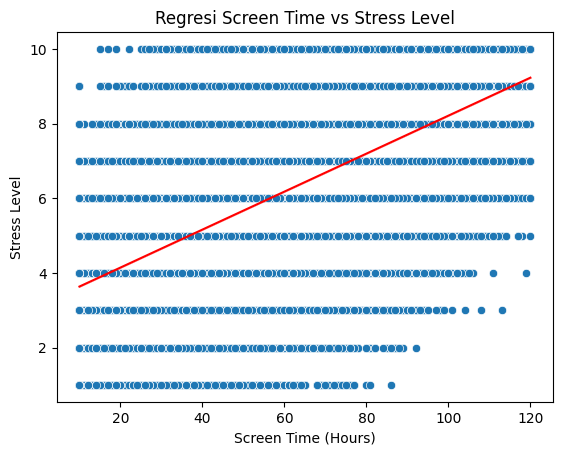

In [ ]:

# IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from google.colab import files

# MEMPROSES DATA
uploaded = files.upload()
data = pd.read_csv("KEBIASAAN DIGITAL VS MENTAL HEALTH.csv", sep=";")

# PILIH VARIABEL
data_sw = data[['screen_time_hours', 'stress_level']]

print(data_sw.head())

# 1. MISSING VALUES
print("\n=== MISSING VALUES ===")
missing = data_sw.isnull().sum()
print(missing)


# 2. OUTLIER DETECTION
print("\n=== OUTLIER DETECTION ===")

def detect_outliers(df):
    for col in df.columns:
        print(f"\nVariabel: {col}")

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers_iqr = df[(df[col] < lower) | (df[col] > upper)][col]

        z = np.abs(stats.zscore(df[col].dropna()))
        outliers_z = df[col][z > 3]

        print("Jumlah outlier (IQR):", len(outliers_iqr))
        print("Jumlah outlier (Z-score):", len(outliers_z))
        print("Batas bawah:", round(lower,2))
        print("Batas atas:", round(upper,2))

detect_outliers(data_sw)

# VISUALISASI OUTLIER
for col in data_sw.columns:
    plt.figure()
    sns.boxplot(x=data_sw[col])
    plt.title(f'Boxplot {col}')
    plt.show()


# 3. STATISTIK DESKRIPTIF
print("\n=== STATISTIK DESKRIPTIF ===")
print(data_sw.describe())


# 4. KORELASI
print("\n=== KORELASI ===")

corr, pval = stats.pearsonr(data_sw['screen_time_hours'], data_sw['stress_level'])

print("Koefisien Korelasi (r):", round(corr,4))
print("p-value:", round(pval,4))

if abs(corr) >= 0.7:
    print("Interpretasi: Korelasi kuat")
elif abs(corr) >= 0.4:
    print("Interpretasi: Korelasi sedang")
else:
    print("Interpretasi: Korelasi lemah")


# 5. REGRESI LINEAR
print("\n=== REGRESI LINEAR ===")

X = data_sw['screen_time_hours']
Y = data_sw['stress_level']

X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()

print(model.summary())

# Persamaan regresi
intercept = model.params[0]
slope = model.params[1]

print("\n=== PERSAMAAN REGRESI ===")
print(f"Y = {round(intercept,4)} + {round(slope,4)}X")

print(f"\nInterpretasi:")
print(f"Setiap kenaikan 1 jam screen time, stress level berubah sebesar {round(slope,2)}")

# 6. UJI NORMALITAS RESIDUAL
print("\n=== UJI NORMALITAS ===")

residuals = model.resid
shapiro = stats.shapiro(residuals)

print("p-value:", round(shapiro.pvalue,4))

if shapiro.pvalue > 0.05:
    print("Kesimpulan: Residual berdistribusi normal")
else:
    print("Kesimpulan: Residual tidak normal")


# 7. UJI HOMOSKEDASTISITAS
print("\n=== UJI HOMOSKEDASTISITAS ===")

bp_test = het_breuschpagan(residuals, X)

print("p-value:", round(bp_test[1],4))

if bp_test[1] > 0.05:
    print("Kesimpulan: Tidak terjadi heteroskedastisitas")
else:
    print("Kesimpulan: Terjadi heteroskedastisitas")


# 8. VISUALISASI REGRESI
plt.figure()
sns.scatterplot(x=data_sw['screen_time_hours'], y=data_sw['stress_level'])
sns.lineplot(x=data_sw['screen_time_hours'], y=model.predict(X), color='red')
plt.title("Regresi Screen Time vs Stress Level")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Stress Level")
plt.show()